# Práctica 2: Aprendizaje automático

El objetivo de esta práctica es aplicar los distintos algoritmos de aprendizaje automático disponibles en la scikit-learn [sklearn](https://scikit-learn.org/stable/) sobre varios conjuntos de datos y aprender a interpretar los resultados obtenidos. La práctica consta de __2 notebooks__ que se entregarán en las tareas de entrega habilitadas en el Campus Virtual. Este notebook corresponde al apartado de __clasificación__.

Lo más importante en esta práctica no es el código Python, sino el análisis de los datos y modelos que construyas y las explicaciones razonadas de cada una de las decisiones que tomes. __No se valorarán trozos de código o gráficas sin ningún tipo de contexto o explicación__.

Finalmente, recuerda establecer el parámetro `random_state` en todas las funciones que tomen decisiones aleatorias para que los resultados sean reproducibles (los resultados no varíen entre ejecuciones).

__Número de grupo: H__

__Nombres de los estudiantes: Jorge Arboleya Carrio, David Esparza Sainz y Cristina Gómez Calvo__

# Apartado 2: Regresión

En este notebook trabajaremos con un conjunto de datos tomado del repositorio de la Universidad de California Irvine. En concreto, se trata de un conjunto de datos sobre distintos vinos del norte de Portugal (vinho verde)  que puedes encontrar [aquí](https://archive.ics.uci.edu/ml/datasets/wine+quality).

El objetivo es modelar la calidad del vino (con un valor de 0 a 10) en base a variables que reflejan sus propiedades físicas y químicas. En concreto, las propiedades son las siguientes:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol

De cara a la memoria que vas a realizar puedes investigar sobre estas propiedades para explicar mejor qué miden y cómo afectan al vino.

La calidad del vino es una variable que toma valores entre 0 y 10.

Para modelar la relación entre la calidad del vino y sus propiedades usaremos una red neuronal.

## 1) Descripción de los datos

Carga el fichero de datos `calidad_vinos.csv` en un dataframe.

Describe el conjunto de datos e identifica aquella variable que tiene unos valores extremos más acusados con respecto a la media, y aquella que está más concentrada en torno a la media. Reflexiona sobre la posible influencia de estas variables a la hora de entrenar el perceptrón multicapa.

Estudia la distribución de la calidad del vino en el conjunto de datos.

In [1]:
import pandas as pd

In [2]:
datos = pd.read_csv('calidad_vinos.csv') #Cargamos el dataset
datos.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Para ver cuales son los datos que tienen valores más alejados a la media, nos fijamos en la desviación típica, que cuanto mayor sea significa que hay más datos alejados de la media. También nos podemos fijar en el caso que tiene valores individuales más alejados de la media. Para ello nos fijamos en el valor máximo y mínimo de cada dato.
Por ejemplo, el dato de ácido cítrico tiene de desviación típica 0.195, que en comparación con la media, que es 0.27, es un valor muy alto, y también tiene casos extremos donde el mínimo es 0 y el máximo es 1, que es casi 4 veces el valor de la media.
Un dato que tiene casi todos los valores agrupados alrededor de la media es la densidad, donde la media es 0.9967… y tanto el valor máximo como el mínimo rondan ese valor. Esto también se puede relacionar con que la desviación típica es muy baja, prácticamente nula.
Otros valores con gran dispersión de los datos son, por ejemplo, el total de dióxido de sulfuro, con un valor de desviación típica no muy diferente a la media, los azúcares residuales y el dióxido de azufre libre.

En cuanto al entrenamiento del perceptrón multicapa, la desviación típica provoca mayor dificultad a la hora del entrenamiento, ya que al calcular las funciones en las diferentes capas salen datos más variados que si todos los valores fueran uniformes. También es importante que los distintos datos, que se pueden tener en unidades muy diferentes, se normalicen o se estandaricen antes de realizar los cálculos, ya que si no tendrán mucho más peso los que tengan unidades más grandes, lo cual no sería justo. Más adelante veremos por que nosotros vamos a elegir estandarizar los datos.


## 2) Selección de variables

Calcula los coeficientes de correlación de Pearson entre la variable de salida y el resto de variables. Crea un nuevo dataframe que contenga la calidad y, selecciona las variables que estén más correlacionadas con él (estableciendo para ello un valor umbral que consideres adecuado).

In [3]:
#Ordenamos los valores según la correlación que tengan con la calidad, donde -1 es que están completamente inversamente relacionados, 1 que están
#directamente relacionados y 0 nada relacionados.
correlacionesCalidad = datos.corr()['quality'].sort_values()
print(correlacionesCalidad)

volatile acidity       -0.390558
total sulfur dioxide   -0.185100
density                -0.174919
chlorides              -0.128907
pH                     -0.057731
free sulfur dioxide    -0.050656
residual sugar          0.013732
fixed acidity           0.124052
citric acid             0.226373
sulphates               0.251397
alcohol                 0.476166
quality                 1.000000
Name: quality, dtype: float64


En primer lugar, cabe decir que un dato esta correlacionado con la variable de salida (quality) cuando el valor del coeficiente de correlación en valor absoluto es cercano a 1. Del mismo modo se puede concluir que está poco relacionado cuando dicho valor es cercano a 0. Así el signo del coeficiente de correlación se debe interpretar como si está directa o indirectamente relacionado. Por ejemplo podemos decir que el pH de los vinos guarda una correlación fuerte con la calidad del vino. En particular, como el signo del coeficiente es negativo cuanto menor sea el pH mejor sera la calidad del vino en general (suponiendo que el resto de parámetros se mantienen constantes). De forma similar se comportan otras variables como el dioxido de azufre libre o la acidez volatil (esta última con una menor correlacion). En cambio se jpuede ver como el alcohol también está bastante relacionado con la calidad del vino pero en este caso de forma directa, es decir, cuanto mayor sea mayor será en términos generales la calidad del vino manteniendo el resto de parámetros constantes. Finalmente queda decir que al igual que el alcohol hay otras variables que también están directamente relacionadas con la calidad del vino pero en menor medida como los sulfatos o el ácido cítrico.

In [4]:
#Seleccionamos como umbral el 0.2
variablesSeleccionadas = correlacionesCalidad[abs(correlacionesCalidad) > 0.2]
print(variablesSeleccionadas)

volatile acidity   -0.390558
citric acid         0.226373
sulphates           0.251397
alcohol             0.476166
quality             1.000000
Name: quality, dtype: float64


Como hemos comentado anteriormente, la correlación cobra sentido en valor absoluto puesto que nos da información igualmente útil que una variable esté directamente relacionada con la calidad (como es el caso del alcohol para incluirlo en este vino) que el hecho de que otras estén indirectamente relacionadas (como es el caso del pH para bajarlo en nuestra búsqueda de "vino perfecto"). Así, atendiendo a los datos de correlación observados, queremos elegir un valor (en valor absoluto) suficientemente alto como para filtrar y eliminar algunas variables que consideramos poco importantes pero suficientemente laxo como para no quedarnos con un número muy reducido de variables. Es por ello por lo que elegimos el valor de 0.2 donde las variables observadas son reducidad más o menos a la mitad con el fin de poner el foco en aquellas que resultan más relevantes para la obtención de un mejor vino.

In [5]:
#Nos quedamos con las variables que superan el umbral y creamos un dataframe con ellas y con la calidad.
datos2 = datos[['volatile acidity', 'citric acid', 'sulphates', 'alcohol', 'quality']]
datos2

,volatile acidity,citric acid,sulphates,alcohol,quality
0,0.700,0.00,0.56,9.4,5
1,0.880,0.00,0.68,9.8,5
2,0.760,0.04,0.65,9.8,5
3,0.280,0.56,0.58,9.8,6
4,0.700,0.00,0.56,9.4,5
...,...,...,...,...,...
1594,0.600,0.08,0.58,10.5,5
1595,0.550,0.10,0.76,11.2,6
1596,0.510,0.13,0.75,11.0,6
1597,0.645,0.12,0.71,10.2,5


## 3) Normalización

Decide si debes o no normalizar los datos de entrada y/o de salida. En caso afirmativo elige razonadamente entre escalarlos o estandarizarlos.


In [6]:
datos2.describe()
#Nos fijamos en la media para decidir si necesitamos escalarlos. En este caso, viendo que hay mucha diferencia entre variables, 
#consideramos que sí es necesario, ya que si no se le daría mayor importancia a las que tienen mayor valor.

,volatile acidity,citric acid,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,0.527821,0.270976,0.658149,10.422983,5.636023
std,0.179060,0.194801,0.169507,1.065668,0.807569
min,0.120000,0.000000,0.330000,8.400000,3.000000
25%,0.390000,0.090000,0.550000,9.500000,5.000000
50%,0.520000,0.260000,0.620000,10.200000,6.000000
75%,0.640000,0.420000,0.730000,11.100000,6.000000
max,1.580000,1.000000,2.000000,14.900000,8.000000


In [7]:
from sklearn.preprocessing import StandardScaler

entrada = datos2.drop(columns=["quality"]) #Debido a que estamos en un problema de clasificación, no es necesario estandarizar la variable de salida (quality). Por ello, la quitamos para no estandarizarla (y posteriormente la introduciremos en el nuevo dataset estandarizado).

scaler = StandardScaler()
datosEstandarizados = pd.DataFrame(scaler.fit_transform(entrada), columns=entrada.columns) #Estandarizamos todas las variables de entrada (es decir, todas salvo quality).

datosEstandarizados["quality"] = datos2["quality"] #Añadimos al nuevo dataframe estandarizado la variable de salida (quality) sin estandarizar.

print(datosEstandarizados.describe())


       volatile acidity   citric acid     sulphates       alcohol      quality
count      1.599000e+03  1.599000e+03  1.599000e+03  1.599000e+03  1599.000000
mean       1.733031e-16 -8.887339e-17  6.754377e-16  1.066481e-16     5.636023
std        1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00     0.807569
min       -2.278280e+00 -1.391472e+00 -1.936507e+00 -1.898919e+00     3.000000
25%       -7.699311e-01 -9.293181e-01 -6.382196e-01 -8.663789e-01     5.000000
50%       -4.368911e-02 -5.636026e-02 -2.251281e-01 -2.093081e-01     6.000000
75%        6.266881e-01  7.652471e-01  4.240158e-01  6.354971e-01     6.000000
max        5.877976e+00  3.743574e+00  7.918677e+00  4.202453e+00     8.000000


Hemos decidido estandarizar los datos debido a que no todos ellos se mueven en la misma escala. Por tanto, al aplicar algoritmos como knn o redes neuronales, los resultados podrían no ser los esperados. Por tanto, estandarizando los datos nos aseguramos de que todos se mueven en una escala similar, dando así la misma importancia a todos los parámetros. Además, al tener desviación típica 1 los datos estandarizados, evitamos el problema de tener datos con valores atípicos que estén aislados pero afecten a la fiabilidad del modelo. De esta forma, al tener los datos parecidos, conseguimos que el modelo aprenda más rápido (debido a la inexistencia de valores atípicos). En conclusión, al estandarizar conseguimos dar la misma importancia a todas las variables para conseguir un aprendizaje más eficiente y fiable de los modelos que vamos a utilizar a continuación.

## 4) Primer modelo: kNN

Antes de pasar a crear las redes neuronales, vamos crear unos primeros modelos más sencillos para comparar. Para ello:

- Crea varios modelos kNN con distintos valores de k (de 2 a 20 vecinos)
- Calcula el MSE de cada uno de ellos, utilizando validación cruzada, para elegir el mejor valor de k

Para elegirlo, pinta el gráfico de MSE para los distintos valores de k.

In [8]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

mse_mean = []
mse_std = []
k_values = range(2,21) #Vamos a utilizar estos valores de k para crear los distintos modelos kNN.
for k in k_values:
    clf = KNeighborsClassifier(k, weights='distance') #Creamos el modelo kNN
    scores = cross_validate(clf, datos2.drop(columns=["quality"]), datos2["quality"], scoring='neg_mean_squared_error', cv=10) #Calculamos el MSE de cada uno de ellos con validación cruzada
    mse_mean.append(-np.mean(scores['test_score']))
    mse_std.append(np.std(scores['test_score']))
mse_mean

[np.float64(0.778062106918239),
 np.float64(0.7298781446540881),
 np.float64(0.660432389937107),
 np.float64(0.6254088050314465),
 np.float64(0.6122327044025158),
 np.float64(0.6009787735849057),
 np.float64(0.5640801886792453),
 np.float64(0.5703262578616352),
 np.float64(0.5790919811320754),
 np.float64(0.5659551886792453),
 np.float64(0.5672169811320754),
 np.float64(0.5534394654088051),
 np.float64(0.5490998427672956),
 np.float64(0.5434630503144654),
 np.float64(0.5372287735849056),
 np.float64(0.5391116352201257),
 np.float64(0.5422169811320754),
 np.float64(0.5453498427672956),
 np.float64(0.5440919811320756)]

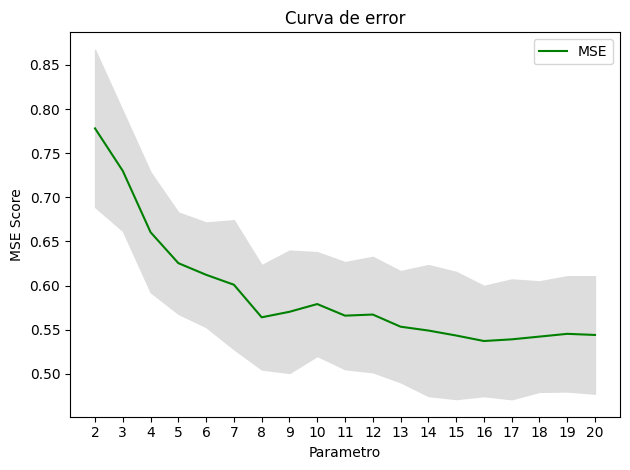

In [9]:
import matplotlib.pyplot as plt

# Dibujamos la línea con el MSE (error cuadrático medio) en el test
plt.plot(k_values, mse_mean, color="g", label="MSE")

# Dibujamos la banda de la desviación típica
lower_limit = np.array(mse_mean) - np.array(mse_std)
upper_limit = np.array(mse_mean) + np.array(mse_std)
plt.fill_between(k_values, lower_limit, upper_limit, color="#DDDDDD")

# Creamos el gráfico
plt.title("Curva de error")
plt.xlabel("Parametro"), plt.ylabel("MSE Score"), plt.legend(loc="best")
plt.tight_layout()
plt.xticks(ticks=range(2, 21))
plt.show()

Hemos creado modelos kNN para todos los valores ente 2 y 20 (ambos incluidos). Tras ello, hemos calculado el error cuadrático medio utilizando validación cruzada y hemos hecho la media del MSE de todos los datos en cada iteración. Esa media de MSE es la que hemos graficado (llamándola MSE Score). Al estar considerando un tipo de error, nos conviene que su valor sea lo menor posible. A medida que aumentamos el valor de k observamos una tendencia del MSE a disminuir (como se puede ver en la gráfica). Eso es señal de que a medida que aumentamos el número de vecinos (k), la precisión del modelo aumenta. Es cierto que no es estrictamente decreciente, ya que encontramos algunos repuntes, como en el 10 y en el 12. Sin embargo, hay una mejoría general del modelo. Observando la gráfica podemos concluir que el mejor valor de k será 16. Observando los valores exactos de MSE, confirmamos que el valor óptimo de k es 16, ya que 0.5372287735849056 es el mínimo de todos los errores.

## 5) Redes neuronales: Entrenamiento y selección

Crea dos redes neuronales de tipo Perceptrón Multicapa:
- La primera con una capa oculta de 250 neuronas
- La segunda con varias capas ocultas entre las que debes distribuir 250 neuronas, como te parezca

Asegúrate de que no salen warnings durante el entrenamiento indicando que no se ha alcanzado la convergencia durante el entrenamiento (para arreglarlo basta con poner un número de max_iter suficientemente grande).

En la configuración del perceptrón debes usar validación cruzada y explorar varios valores para el parámetro `alpha` que controla el coeficiente de regularización L2.

Para elegir el valor adecuado de dicho coeficiente pinta la curva de aprendizaje para cada perceptrón. En la curva debes pintar una línea que represente el error medio de las distintas particiones de validación y un área sombreada que represente la desviación típica.

Una vez tengas la curva de aprendizaje:
  - Identifica las diferencias de comportamiento entre ambos perceptrones, razona o especula sobre por qué se dan. ¿Hay alguno que domine al otro? ¿Es el comportamiento de uno más volátil que el del otro?
  - Determina de manera razonada con qué perceptrón te quedas y el valor óptimo del parámetro de regularización.

In [10]:
from sklearn.neural_network import MLPClassifier
RANDOM_STATE=333

mse_mean1 = []  # Perceptrón 1
mse_std1 = []
mse_mean2 = []  # Perceptrón 2
mse_std2 = []

# Una única capa oculta con 250 neuronas
regul_param_range = np.arange(0.1, 2.1, step=0.2) # [0.5, 0.75,  ..., 2]
for regul_param in regul_param_range:
    # Ponemos un valor de iteraciones suficientemente grande para que converja el algoritmo.
    mlp1 = MLPClassifier(hidden_layer_sizes=(250, ), activation='relu', solver='adam', alpha=regul_param, batch_size=100,
             learning_rate_init=0.001, max_iter=500, random_state=RANDOM_STATE)
    #Hacemos validación cruzada.
    scores1 = cross_validate(mlp1, datos2.drop(columns=["quality"]), datos2["quality"], scoring='neg_mean_squared_error', cv=10)

    mse_mean1.append(-np.mean(scores1['test_score']))
    mse_std1.append(np.std(scores1['test_score']))
    
#Tres capas ocultas con 250 neuronas en total
for regul_param in regul_param_range:
    mlp2 = MLPClassifier(hidden_layer_sizes=(100, 100, 50), activation='relu', solver='adam', alpha=regul_param, batch_size=100,
             learning_rate_init=0.001, max_iter=500, random_state=RANDOM_STATE)

    scores2 = cross_validate(mlp2,  datos2.drop(columns=["quality"]), datos2["quality"], scoring='neg_mean_squared_error', cv=10)

    mse_mean2.append(-np.mean(scores2['test_score']))
    mse_std2.append(np.std(scores2['test_score']))






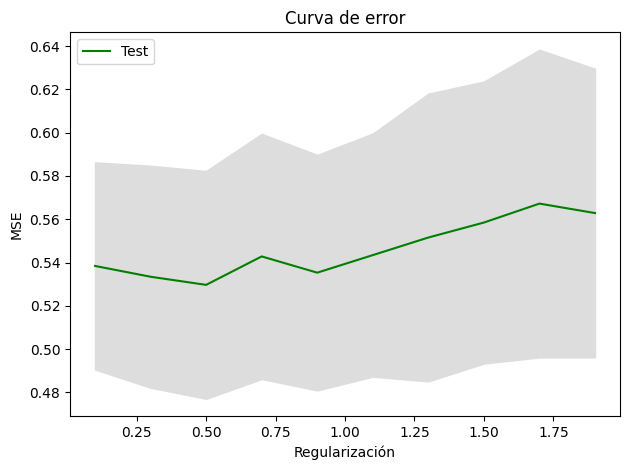

In [11]:

# Dibujamos la línea de la exactitud media en las partes de test
plt.plot(regul_param_range, mse_mean1, color="g", label="Test")

# Dibujamos la banda de la desviación típica
lower_limit = np.array(mse_mean1) - np.array(mse_std1)
upper_limit = np.array(mse_mean1) + np.array(mse_std1)
plt.fill_between(regul_param_range, lower_limit, upper_limit, color="#DDDDDD")

# Creamos el gráfico
plt.title("Curva de error")
plt.xlabel("Regularización"), plt.ylabel("MSE"), plt.legend(loc="best")
plt.tight_layout()
plt.show()


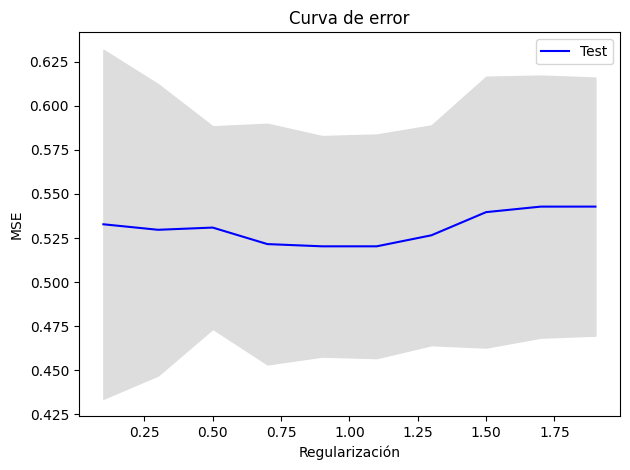

In [12]:
# Dibujamos la línea de la exactitud media en las partes de test
plt.plot(regul_param_range, mse_mean2, color="b", label="Test")

# Dibujamos la banda de la desviación típica
lower_limit = np.array(mse_mean2) - np.array(mse_std2)
upper_limit = np.array(mse_mean2) + np.array(mse_std2)
plt.fill_between(regul_param_range, lower_limit, upper_limit, color="#DDDDDD")

# Creamos el gráfico
plt.title("Curva de error")
plt.xlabel("Regularización"), plt.ylabel("MSE"), plt.legend(loc="best")
plt.tight_layout()
plt.show()

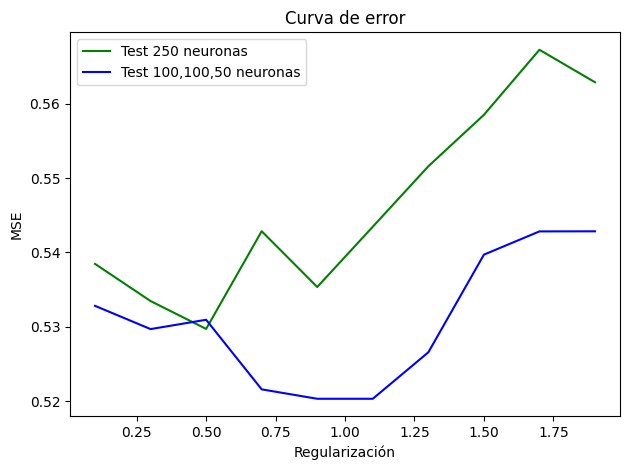

In [13]:
# Dibujamos la línea de la exactitud media en las partes de test
plt.plot(regul_param_range, mse_mean1, color="g", label="Test 250 neuronas")
plt.plot(regul_param_range, mse_mean2, color="b", label="Test 100,100,50 neuronas")
plt.title("Curva de error")
plt.xlabel("Regularización"), plt.ylabel("MSE"), plt.legend(loc="best")
plt.tight_layout()
plt.show()

El perceptrón multicapa puede realizar cálculos más complejos en las diferentes capas mientras que el de una capa no tiene esa posibilidad, por eso para problemas relativamente complejos o con más cálculos suele ser mejor el multicapa, como es nuestro caso. Además, al tener casos de valores más dispersos, el unicapa no tiene la posibilidad de corregirlo mientras que el multicapa es más capaz de minimizar esos errores a través de las distintas capas.
En cuanto al alpha, que controla el coeficiente de regularización, podemos ver en las gráficas que donde mejor van los entrenamientos es cuando el parámetro no toma valores ni muy altos ni muy bajos, es decir, valores medios.
En nuestro caso, también podemos observar en las gráficas en las que se ve el aprendizaje que es mejor el perceptrón multicapa, ya que el error cuadrático medio es menor para (prácticamente) todos los valores de alpha. Además vemos que el perceptrón multicapa, que es el mejor, alcanza el menor error cuando alpha=1.1 aproximadamente, por lo cual utilizamos este valor donde nos lo pide.
En cuanto a la volatilidad, el MLP tiene más usos y diferentes aplicaciones que el de una capa ya que se puede utilizar para cálculos más complejos. Sin embargo, el de una capa es más eficiente y sencillo pero sirve sobre todo para cálculos simples y lineales.


## 6) Medición y análisis del error

Elige la mejor configuración del apartado anterior y usa la función `cross_val_predict` para realizar una predicción de la calidad de todos los vinos usando validación cruzada.

A continuación:
- Muestra varias medidas de error y razona sobre si el error te parece pequeño o no para el problema que estás analizando
- Muestra el histograma de la distribución del error o del error en valor absoluto, y razona de nuevo si te parece que el modelo ha predicho bien o no. Identifica los vinos para los cuales el modelo ha fallado más.
- Analiza el error cometido para los vinos según su puntuación de calidad observada (3, 4, etc). Describe lo que sucede, explica por qué crees que sucedió y razona de nuevo si te parece que el modelo funciona bien o tiene limitaciones.
- Compara los resultados obtenidos (al menos MSE) con el mejor modelo de kNN.

MSE: 0.5203252032520326
MAE: 0.45528455284552843


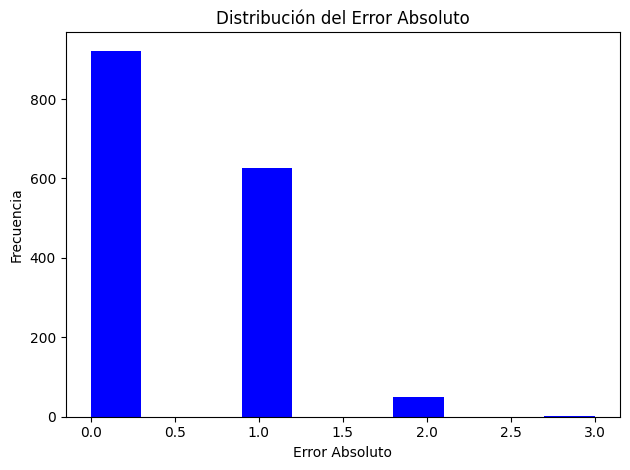

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_predict

mlp3 = MLPClassifier(hidden_layer_sizes=(100, 100, 50), activation='relu', solver='adam', alpha=1.1, batch_size=100,
             learning_rate_init=0.001, max_iter=500, random_state=RANDOM_STATE)

scores3 = cross_val_predict(mlp3, datos2.drop(columns=["quality"]), datos2["quality"], cv=10)

#Calculamos medidas de error
#Error cuadrático medio
mse = mean_squared_error(datos2["quality"], scores3)
print("MSE:", mse)
#Error absoluto
mae = mean_absolute_error(datos2["quality"], scores3)
print("MAE:", mae)

errorAbs = np.abs(datos2["quality"] - scores3)
plt.hist(errorAbs, bins=10, color='b')
plt.title("Distribución del Error Absoluto")
plt.xlabel("Error Absoluto")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

En primer lugar, para el proceso de selección de cuál es la mejor configuración del apartado anterior nos fijamos en la gráfica del MSE para los distintos tests. Es fácil observar como en general es mejor el test de 100,100 y 50 neuronas con casos muy particulares de intersección del MSE con el test de 250 neuronas para valores del parámetro alfa ( que controla el coeficiente de regularización) próximos a 0.5. En cualquier caso como es algo muy puntual, podemos ignorarlo y pasamos a utilizar el primer test mencionado. Observando así la evolución del mse para distintos valores de regularización (alfa) concluimos que el valor óptimo es algo cercano a 1.1 (valor para el que se observa un mínimo en la línea de color azul implicando un menor error que evidentemente es lo que buscamos). Con estos valores creamos nuestra red neuronal multicapa de 3 capas ocultas con 250 neuronas en total y posteriormente realizamos la validación cruzada.

Una vez calculado todo pasamos al cálculo de los errores. El valor obtenido del MSE representa un bastante buen funcionamiento del modelo puesto que un valor de 0.5 para una variable objetivo que toma valores de 3 a 8 se podría considerar bastante pequeño. Análogamente el MAE observado corrobora está información indicando como aunque el modelo pueda producir algunos errores estos son o poco frecuentes o poco significativos o una mezcla de ambos. Finalmente en cuanto al error absoluto incluimos la gráfica. Aquí se observa que en la mayoría de casos (un número cercano a 900) el error absoluto observado es pequeño muy próximo a 0 y por tanto nuestro sistema funcniona correctamente. NO obstante hay un número nada despreciable de casos (de unos 600 que representa algo más de la mitad) donde el error absoluto observado sube a valores cercanos a 1. Este error ya sí que comienza a ser bastante relevante puesto que los valores de calidad van del 3 al 8. Y por tanto en un recorrido total de valor 5 un fallo de 1 representa un fallo significativo (de magnitud del 20% del error total que se puede cometer). Finalmente hay casos donde se comete un error aún mayor y por tanto más preocupante de valores en torno a 2. Sin embargo aquí si que la frecuencia en la que aparece es muy menor y por tanto no es algo que influya en gran medida (aparece en unos 30 casos).

In [15]:
# Analizar error según calidad observada
calidades = {}
for q in datos2["quality"].unique():
    errores_por_calidad = errorAbs[datos2["quality"] == q]
    calidades[q] = {
        "promedio": errores_por_calidad.mean(),
        "std": errores_por_calidad.std(),
        "conteo": len(errores_por_calidad),
    }

print("\nAnálisis de errores según calidad observada:")
for q, c in calidades.items():
    print(f"Calidad: {q} -> Error promedio: {c['promedio']}, "
          f"Desviación típica: {c['std']}, Número de vinos: {c['conteo']}")



Análisis de errores según calidad observada:
Calidad: 5 -> Error promedio: 0.2540381791483113, Desviación típica: 0.4456512006691512, Número de vinos: 681
Calidad: 6 -> Error promedio: 0.4090909090909091, Desviación típica: 0.49205185481747094, Número de vinos: 638
Calidad: 7 -> Error promedio: 0.8944723618090452, Desviación típica: 0.47558533630786015, Número de vinos: 199
Calidad: 4 -> Error promedio: 1.2075471698113207, Desviación típica: 0.40943162132389455, Número de vinos: 53
Calidad: 8 -> Error promedio: 1.7222222222222223, Desviación típica: 0.4608885989624768, Número de vinos: 18
Calidad: 3 -> Error promedio: 2.1, Desviación típica: 0.31622776601683794, Número de vinos: 10


En cuanto a los errores según las calidades, como era de esperar, el error absoluto es inversamente proporcional al número de ejemplares que hay de esa calidad. Es decir, cuantos más ejemplos de una calidad dada haya, menor error absoluto habrá ya que se regularizará bastante más y los ejemplos converjerán hacia la media real. 
Por ejemplo, si observamos los vinos de calidad 3, únicamente tenemos 10 ejemplares, por lo que el error promedio es de 2.1, que en una escala de valores de calidad del 3 al 8, es un error muy grande. Sin embargo, los vinos de calidad 5, en los que hay 681 ejemplares, tienen un error medio de 0.25, lo cual es mucho más considerable y un error relativamente adecuado, en comparación con el resto.


MSE Knn: 0.5372107567229518
MAE Knn: 0.46216385240775487


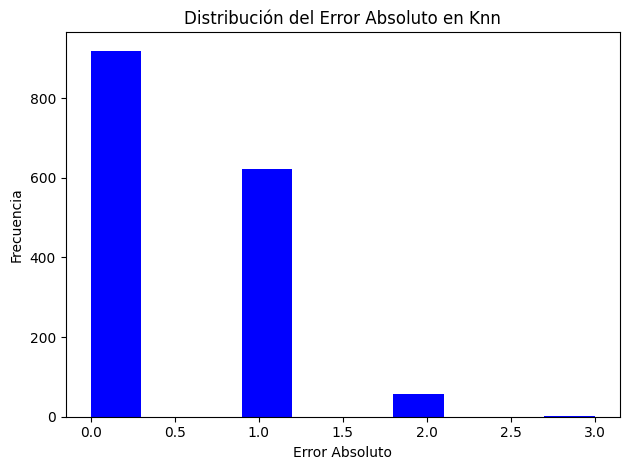


Análisis de errores según calidad observada en knn:
Calidad: 5 -> Error promedio: 0.30837004405286345, Desviación típica: 0.4839213152327719, Número de vinos: 681
Calidad: 6 -> Error promedio: 0.44043887147335425, Desviación típica: 0.5062198334768383, Número de vinos: 638
Calidad: 7 -> Error promedio: 0.6934673366834171, Desviación típica: 0.5958675346729458, Número de vinos: 199
Calidad: 4 -> Error promedio: 1.2264150943396226, Desviación típica: 0.576511706264571, Número de vinos: 53
Calidad: 8 -> Error promedio: 1.3888888888888888, Desviación típica: 0.6978023391872253, Número de vinos: 18
Calidad: 3 -> Error promedio: 2.0, Desviación típica: 0.4714045207910317, Número de vinos: 10


In [16]:
clf2 = KNeighborsClassifier(16, weights='distance') #Creamos el modelo kNN para el mejor k que hemos observado anteriormente
scoresClf = cross_val_predict(clf2, datos2.drop(columns=["quality"]), datos2["quality"], cv=10)
mse_knn =  mean_squared_error(datos2["quality"], scoresClf)
print("MSE Knn:",mse_knn)
mae_knn = mean_absolute_error(datos2["quality"], scoresClf)
print("MAE Knn:",mae_knn)
errorAbsClf = np.abs(datos2["quality"] - scoresClf)
plt.hist(errorAbsClf, bins=10, color='b')
plt.title("Distribución del Error Absoluto en Knn")
plt.xlabel("Error Absoluto")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Analizar error en knn según calidad observada
calidades = {}
for q in datos2["quality"].unique():
    errores_por_calidad = errorAbsClf[datos2["quality"] == q]
    calidades[q] = {
        "promedio": errores_por_calidad.mean(),
        "std": errores_por_calidad.std(),
        "conteo": len(errores_por_calidad),
    }

print("\nAnálisis de errores según calidad observada en knn:")
for q, c in calidades.items():
    print(f"Calidad: {q} -> Error promedio: {c['promedio']}, "
          f"Desviación típica: {c['std']}, Número de vinos: {c['conteo']}")


El mejor modelo de knn es con k=16, como hemos visto anteriormente. Al calcular las diferentes medidas del error, observamos que son bastante similares a las obtenidas con la mejor configuración de la red neuronal, teniendo esta última un error ligeramente inferior. En cuanto a las gráficas de la distribución del error absoluto, observamos que ambas son prácticamente idénticas. Si nos fijamos en el error en función de la calidad del vino, vemos la misma tendencia a disminuir cuantos más vinos haya de esa calidad, debido a que tiene más datos con los que aprender el modelo. Además, los valores de error para cada calidad con knn son bastante similares a los errores cometidos con la red neuronal (en algunas calidades el error absoluto medio es mayor en knn y en otras lo es en la red neuronal). En cuanto a la desviación típica, es superior en knn para todas las calidades, siendo más notoria la diferencia cuantos menos vinos haya de esa calidad.